In [ ]:
# Importar la librería para acceder a Google Drive
from google.colab import drive

# Montar Google Drive en la carpeta /content/drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Instalar la librería Ultralytics (YOLOv8)
!pip install ultralytics

# Importar la librería Ultralytics
import ultralytics

# Verificar que la instalación y el entorno funcionen correctamente
ultralytics.checks()

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.3/107.7 GB disk)


In [ ]:
# Importar la librería para trabajar con archivos YAML
import yaml

# ==========================================
# CONFIGURACIÓN DEL CONJUNTO DE DATOS
# ==========================================

# Definir las rutas del conjunto de datos dentro de Google Drive
dataset_yaml = {
    'train': '/content/drive/MyDrive/detecting helmets.yolov8/train/images',  # Imágenes de entrenamiento
    'val': '/content/drive/MyDrive/detecting helmets.yolov8/valid/images',     # Imágenes de validación
    'test': '/content/drive/MyDrive/detecting helmets.yolov8/test/images',     # Imágenes de prueba

    # Número de clases que se desean detectar
    'nc': 1,

    # Nombre de la clase
    'names': ['helmets']
}

# Ruta donde se guardará el archivo de configuración data.yaml
ruta_yaml = '/content/drive/MyDrive/detecting helmets.yolov8/data.yaml'

# Crear o sobrescribir el archivo data.yaml
with open(ruta_yaml, 'w') as archivo:
    yaml.dump(dataset_yaml, archivo, default_flow_style=False)

# Mensaje de confirmación
print("¡Archivo data.yaml corregido y guardado con éxito en Google Drive!")

¡Archivo data.yaml corregido y guardado con éxito en tu Google Drive!


In [23]:
# ==========================================
# ENTRENAMIENTO DEL MODELO YOLOv8
# ==========================================

# Importar la clase YOLO de la librería Ultralytics
from ultralytics import YOLO

# Cargar el modelo YOLOv8 Nano preentrenado
# Este es el modelo más ligero y rápido de la familia YOLOv8
modelo = YOLO('yolov8n.pt')

# Iniciar el entrenamiento utilizando el conjunto de datos configurado
resultados = modelo.train(

    # Ruta del archivo de configuración del conjunto de datos
    data='/content/drive/MyDrive/detecting helmets.yolov8/data.yaml',

    # Número de épocas de entrenamiento
    # Una época equivale a recorrer todas las imágenes una vez
    epochs=20,

    # Tamaño al que se redimensionarán las imágenes
    imgsz=640,

    # Generar automáticamente gráficas de entrenamiento
    plots=True
)

# Al finalizar, el modelo entrenado se guardará automáticamente
# en la carpeta runs/detect/train dentro del entorno de Colab.

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/detecting helmets.yolov8/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov


image 1/1 /content/drive/MyDrive/detecting helmets.yolov8/test/images/10002 (1)_jpg.rf.Cy6W5ms0E6BuH8G1XVj6.jpg: 448x640 1 helmets, 156.6ms
Speed: 3.7ms preprocess, 156.6ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


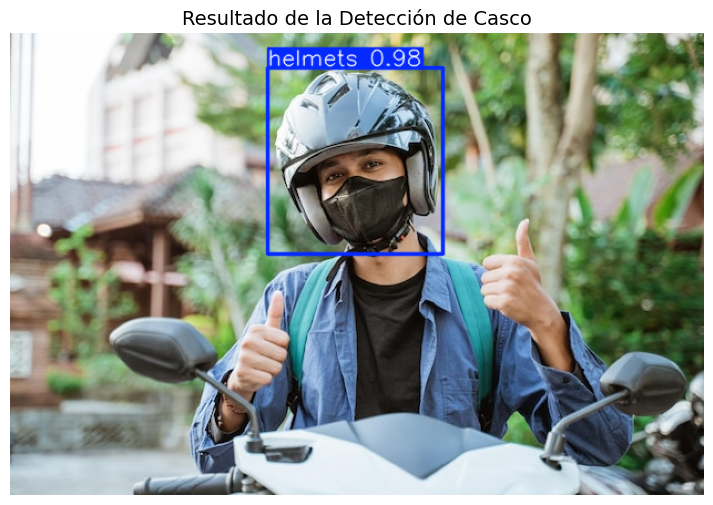

In [35]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Cargar el modelo entrenado con tus pesos de train3
model_entrenado = YOLO('runs/detect/train-4/weights/best.pt')

# 2. DEFINE AQUÍ LA IMAGEN QUE QUIERES PROCESAR
# Puedes cambiar 'image_0.jpg' por el nombre de cualquier foto que esté en tu carpeta de test
ruta_imagen = '/content/drive/MyDrive/detecting helmets.yolov8/test/images/10002 (1)_jpg.rf.Cy6W5ms0E6BuH8G1XVj6.jpg'

# 3. Ejecutar la predicción forzando una confianza baja (0.15) para asegurar que pinte el cuadro
# Desactivamos 'save' para manejar el guardado y mostrado manualmente de forma limpia
results = model_entrenado.predict(source=ruta_imagen, conf=0.9, save=False)

# 4. Obtener la imagen con los cuadros dibujados (YOLO devuelve los pixeles en formato BGR)
imagen_con_cuadros_bgr = results[0].plot()

# 5. Convertir de BGR (OpenCV) a RGB (Matplotlib) para que los colores se vean reales
imagen_con_cuadros_rgb = cv2.cvtColor(imagen_con_cuadros_bgr, cv2.COLOR_BGR2RGB)

# 6. Mostrar la imagen procesada aquí abajo en Colab
plt.figure(figsize=(10, 6))
plt.imshow(imagen_con_cuadros_rgb)
plt.axis('off')  # Oculta los ejes con los números de pixeles
plt.title("Resultado de la Detección de Casco", fontsize=14)
plt.show()

✓ Trained model loaded successfully from: runs/detect/train-4/weights/best.pt

=== UPLOAD YOUR IMAGE ===
Please click the button below to upload a JPG or PNG image from your computer.


Saving WhatsApp Image 2026-06-18 at 3.11.22 PM.jpeg to WhatsApp Image 2026-06-18 at 3.11.22 PM (1).jpeg
✓ Image 'WhatsApp Image 2026-06-18 at 3.11.22 PM (1).jpeg' uploaded successfully.

Running helmet detection on WhatsApp Image 2026-06-18 at 3.11.22 PM (1).jpeg...

image 1/1 /content/WhatsApp Image 2026-06-18 at 3.11.22 PM (1).jpeg: 640x384 1 helmets, 146.1ms
Speed: 5.4ms preprocess, 146.1ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict-7


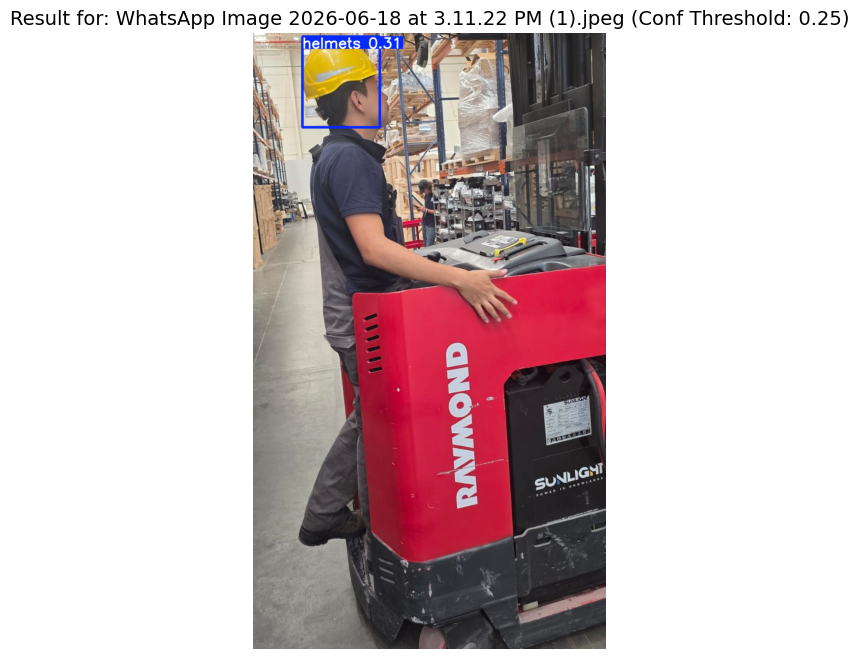


--- Detection Details ---
Results saved permanently in: /content/runs/detect/predict-7
✓ Total helmets detected: 1
   -> Detection 1: Class='helmets', Confidence=31.1%


In [32]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os
from google.colab import files # Special module for Colab uploads

# =========================================================================
# 1. LOAD YOUR TRAINED MODEL (ensure the path matches your train run)
# We will use your train3 results, assuming they are the best.
# =========================================================================
try:
    best_weights_path = 'runs/detect/train-4/weights/best.pt'
    custom_model = YOLO(best_weights_path)
    print(f"✓ Trained model loaded successfully from: {best_weights_path}")
except Exception as e:
    print(f"X Error: Could not find or load the trained model at {best_weights_path}")
    print("X Make sure your training in train3 completed successfully.")
    print("X (You can try changing 'train3' to 'train', 'train1', etc., if needed.)")
    raise e

# =========================================================================
# 2. PROMPT TO UPLOAD A NEW IMAGE FROM YOUR COMPUTER
# =========================================================================
print("\n=== UPLOAD YOUR IMAGE ===")
print("Please click the button below to upload a JPG or PNG image from your computer.")
uploaded = files.upload() # This will stop execution and open the upload dialog

# Get the filename of the uploaded image
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    print(f"✓ Image '{uploaded_filename}' uploaded successfully.")
else:
    print("X No image uploaded. Predictions cannot proceed.")

# =========================================================================
# 3. RUN PREDICTION ON THE UPLOADED IMAGE
# Note: We are using conf=0.25, a common starting point.
# You can lower it (e.g., to 0.15) if it misses obvious detections.
# =========================================================================
if uploaded:
    print(f"\nRunning helmet detection on {uploaded_filename}...")

    results = custom_model.predict(
        source=uploaded_filename,
        save=True, # Will save a permanent record in runs/detect/predictX
        conf=0.25,  # Detection confidence threshold (0.25 is standard)
        # iou=0.45, # (Optional) Non-Maximum Suppression threshold
    )

    # =========================================================================
    # 4. GET THE PLOTTED IMAGE AND DISPLAY IT
    # =========================================================================
    # YOLO.predict can return multiple results; we want the first one.
    annotated_img_bgr = results[0].plot(labels=True, conf=True)

    # Convert the resulting BGR image (from OpenCV) to RGB (for Matplotlib display)
    annotated_img_rgb = cv2.cvtColor(annotated_img_bgr, cv2.COLOR_BGR2RGB)

    # Define the display size
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off') # Hide axes
    plt.title(f"Result for: {uploaded_filename} (Conf Threshold: 0.25)", fontsize=14)
    plt.show()

    # == Optional Diagnostics ==
    print(f"\n--- Detection Details ---")
    print(f"Results saved permanently in: {results[0].save_dir}")
    if len(results[0].boxes) > 0:
        print(f"✓ Total helmets detected: {len(results[0].boxes)}")
        for i, box in enumerate(results[0].boxes):
            class_id = int(box.cls.item())
            class_name = results[0].names[class_id]
            confidence = box.conf.item()
            print(f"   -> Detection {i+1}: Class='{class_name}', Confidence={confidence*100:.1f}%")
    else:
        print("X No helmets were detected in this image at this confidence level.")
        print("X Consider trying an image with better lighting/angle, or re-running")
        print("X with a lower confidence threshold (e.g., conf=0.15) in the predict line.")

else:
    # This block executes if files.upload() failed or was cancelled
    pass